# Concept swaps in J-lens coordinates — Qwen3-4B, pre-fitted lens

Replace the model's representation of one concept with another's in J-lens coordinates and
check that the answer changes accordingly, as in the paper's two-hop and
flexible-generalization swaps (`data/experiments/probe-swap.json`,
`flexible-generalization.json`). Example: *"The capital of France is the city of"* with
France -> China should answer *Beijing*.

This is the GPT-2 XL experiment of `notebooks/jacobian_lens/concept_swap.ipynb` rerun on
Qwen3-4B with the lens downloaded from `neuronpedia/jacobian-lens` — nothing is fitted here.

Only trials the model answers correctly without intervention are swapped and scored (§2).

**Answer (this run, §3).** J-lens swaps work on Qwen3-4B and are specific. Of 282 trials the
model answers 115 correctly with scorable answers (flexible 76, two-hop 39). On those, the
best setting flips **50%** of flexible-generalization swaps (alpha 2, band 8-16; Wilson 95%
CI [39, 61]) and **51%** of two-hop swaps (alpha 2, band 20-28; CI [36, 66]), while random
directions of the same per-position norm stay at **0-4%**. The paper's "J matters in early
and middle layers" holds sharply here: at alpha 1 logit-lens directions score **exactly
0.000** at bands 8-16, 12-20 and 16-24 on both sets, where J-lens directions reach
0.18-0.38, and they only become competitive from band 20-28 upward. Median log10 rank gain
for the swapped-in answer is 1.46 for J at alpha 1 in band 20-28 on two-hop, against 0.55
for logit and 0.04 for random. For scale, the GPT-2 XL run in
`notebooks/jacobian_lens/concept_swap.ipynb` reached 68% and 47% on the same two sets, but
from a far weaker baseline — it answered only 33% and 17% of the prompts correctly, where
Qwen3-4B answers 45% and 48%.

## Method

**Lens vectors.** The J-lens logit of token `t` at layer `l` is `u_t . norm(J_l h)`, so its
direction in the residual stream is a row of `W_U J_l` with the final norm's gain folded in.
Qwen3 normalizes with RMSNorm, which has **no centering term**, unlike GPT-2's LayerNorm:

```
GPT-2 (LayerNorm):  v_t = J_l^T C(gamma * u_t)
Qwen3  (RMSNorm):   v_t = J_l^T   (gamma * u_t)
```

`jlens.workspace.lens_direction` probes the model's own norm rather than assuming either,
so the same code is correct on both. Carrying GPT-2's centering over to Qwen would tilt
every direction and quietly turn this experiment into a null result. The logit-lens control
is the same formula with `J_l = I`.

**Swap (clamping).** For source `s` and target `t`, `V = [v_s v_t]` and coordinates
`c = V^+ h`. A clean pass records `c_clean` at every band layer and position; the patched
pass sets, after each band block, `h <- h + V(c* - V^+ h)` with
`c* = c_clean + alpha (swap(c_clean) - c_clean)`. At `alpha = 1` the two coordinates are
exchanged and the component of `h` orthogonal to `span(V)` is kept.

Clamping to the clean coordinates is what makes a band work: adding
`alpha V(swap(c) - c)` to the already-patched stream at each layer undoes the swap at every
second layer, and with `alpha > 1` the overshoot compounds.

**Positions.** Qwen3 has no BOS token (`bos_token_id` is `None`), so unlike the GPT-2 run
there is no sink token to skip — every prompt position is patched.

**Question filter.** A swap can only show the answer changing *because of* the swap if
the model gave the right answer before it. One batched clean pass first checks each trial:
the greedy next token at the final position must be a spelling of `answer`, and both
answers must be scorable (§1). Only those trials are swapped; the rest are not run at all.

**Grid.** Five bands as fractions of depth, `alpha` in {1, 2}, and three direction modes:
`J`, `logit` (the same clamp without `J_l`) and `random` (a random update matched to the J
update's per-position norm). Scoring follows the GPT-2 notebook: a trial succeeds when the
greedy next token at the final position is a spelling of the swapped concept's answer.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "workspace.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.evaluation import single_token_ids, spelling_ids
from jlens.workspace import ClampSwap, final_norm_centers, record_residuals

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = os.environ.get("JLENS_MODEL_ID", "Qwen/Qwen3-4B")
LENS_REPO = "neuronpedia/jacobian-lens"
LENS_FILE = {  # lenses fitted by this library's fit_lens.py on 1000 WikiText-103 x 128 tokens
    "Qwen/Qwen3-4B": "qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt",
    "Qwen/Qwen3-1.7B": "qwen3-1.7b/jlens/Salesforce-wikitext/Qwen3-1.7B_jacobian_lens.pt",
}[MODEL_ID]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
SLUG = MODEL_ID.split("/")[-1].lower()
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / SLUG))
RUN_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=DTYPE).to(DEVICE)
model = jlens.from_hf(hf_model, tokenizer)
lens = jlens.JacobianLens.from_pretrained(LENS_REPO, filename=LENS_FILE)

# Qwen3 is RMSNorm, so lens directions carry no centering term; probed, not assumed.
CENTERS = final_norm_centers(model)
assert lens.d_model == model.d_model, (lens.d_model, model.d_model)
print(f"{model}  layout={model.layout.path}  centers={CENTERS}")
print(f"lens: {lens.n_prompts} prompts, layers {lens.source_layers[0]}-{lens.source_layers[-1]}")
print(f"tokenizer: bos_token_id={tokenizer.bos_token_id}  dtype={DTYPE}  device={DEVICE}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

HFLensModel(Qwen3ForCausalLM, n_layers=36, d_model=2560)  layout=model  centers=False
lens: 479 prompts, layers 0-34
tokenizer: bos_token_id=None  dtype=torch.bfloat16  device=cuda


In [5]:
# Bands as fractions of depth, so one set of settings covers models of different depth.
# On Qwen3-4B (36 layers) these are 8-16, 12-20, 16-24, 20-28 and the wide 12-28.
BAND_FRACTIONS = [(0.22, 0.44), (0.33, 0.55), (0.44, 0.66), (0.55, 0.78), (0.33, 0.78)]
BAND_LAYERS = {
    f"{round(lo * model.n_layers)}-{round(hi * model.n_layers)}":
        list(range(round(lo * model.n_layers), round(hi * model.n_layers)))
    for lo, hi in BAND_FRACTIONS
}
BANDS = list(BAND_LAYERS)
# Three single layers in the middle of the band, for per-layer readout tables.
WORKSPACE_LAYERS = [round(f * model.n_layers) for f in (0.33, 0.5, 0.66)]
BANDS, WORKSPACE_LAYERS

(['8-16', '12-20', '16-24', '20-28', '12-28'], [12, 18, 24])

In [6]:
# Swaps on correctly answered trials only; a new name so an older all-trials cache is not reused.
OUT_PATH = RUN_DIR / "swap_trials_correct.csv"
ALPHAS = [1.0, 2.0]
MODES = ["J", "logit", "random"]
RUN_INFO = {"model_id": MODEL_ID, "dtype": str(DTYPE), "lens_file": LENS_FILE,
            "lens_n_prompts": lens.n_prompts, "centers": CENTERS,
            "bands": BANDS, "alphas": ALPHAS, "modes": MODES}
RUN_INFO

{'model_id': 'Qwen/Qwen3-4B',
 'dtype': 'torch.bfloat16',
 'lens_file': 'qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt',
 'lens_n_prompts': 479,
 'centers': False,
 'bands': ['8-16', '12-20', '16-24', '20-28', '12-28'],
 'alphas': [1.0, 2.0],
 'modes': ['J', 'logit', 'random']}

## 1. Trials

`probe-swap` is 90 two-hop prompts where the swap replaces the bridge entity;
`flexible-generalization` crosses 4 argument values with 4 function templates per category,
giving every ordered pair within a category.

In [7]:
def load_trials():
    trials = []
    for item in json.loads((Path(REPO_DIR) / "data/experiments/probe-swap.json").read_text())["items"]:
        trials.append({"set": "probe-swap", "group": item["category"], "name": item["name"],
                       "prompt": item["prompt"].rstrip(), "source": item["intermediate"],
                       "target": item["swap_to"], "answer": item["answer"],
                       "swap_answer": item["swap_answer"]})
    categories = json.loads(
        (Path(REPO_DIR) / "data/experiments/flexible-generalization.json").read_text())["categories"]
    for category in categories:
        for func in category["funcs"]:
            for source in category["args"]:
                for target in category["args"]:
                    if target != source:
                        trials.append({
                            "set": "flexible", "group": f"{category['name']}/{func['name']}",
                            "name": f"{func['name']}:{source}->{target}",
                            "prompt": func["template"].format(arg=source).rstrip(),
                            "source": source, "target": target,
                            "answer": func["answers"][source],
                            "swap_answer": func["answers"][target]})
    return pd.DataFrame(trials)


trials = load_trials()
display(trials.groupby("set").size().to_frame("trials"))
display(trials.groupby("set").head(2)[["set", "prompt", "source", "target", "answer", "swap_answer"]])

,trials
set,
flexible,192
probe-swap,90


,set,prompt,source,target,answer,swap_answer
0,probe-swap,Fact: The language spoken in the country where...,Brazil,Mexico,Portuguese,Spanish
1,probe-swap,Fact: The hard covering on the back of the slo...,turtle,snake,shell,scale
90,flexible,The capital of France is the city of,France,Canada,Paris,Ottawa
91,flexible,The capital of France is the city of,France,China,Paris,Beijing


### Single-token concepts

The swap exchanges one vocabulary direction for another, so both concepts need a
single-token form. Trials where either side is multi-token are kept but flagged.

In [8]:
def concept_token(word):
    ids = tokenizer.encode(" " + word, add_special_tokens=False)
    return ids[0], len(ids) == 1


trials["source_id"], trials["source_single"] = zip(*trials.source.map(concept_token), strict=True)
trials["target_id"], trials["target_single"] = zip(*trials.target.map(concept_token), strict=True)
print(f"both single-token: {(trials.source_single & trials.target_single).mean():.0%}")
display(trials.groupby("set")[["source_single", "target_single"]].mean().round(3))

both single-token: 99%


,source_single,target_single
set,,
flexible,1.000,1.000
probe-swap,0.989,0.989


### Scorable answers

Scoring uses `spelling_ids`, which falls back to the *first* token of `" word"` when a word
has no single-token spelling. On Qwen3 a numeral like `26` tokenizes as `2`+`6`, so that
fallback returns a bare space — a very common next token, which would score as a hit for
any prompt whose continuation happens to be whitespace. A "correct" baseline on such a trial
is a whitespace match, so trials whose answer or swap answer is unscorable are excluded
along with the ones the model gets wrong (§2).

In [9]:
def scorable(word):
    return len(single_token_ids(tokenizer, str(word))) > 0


trials["scorable"] = trials.answer.map(scorable) & trials.swap_answer.map(scorable)
display(trials.groupby("set").scorable.agg(["sum", "size"]))
display(trials[~trials.scorable].head(6)[["set", "name", "answer", "swap_answer"]])
print("example fallback:", repr(sorted(spelling_ids(tokenizer, "26"))),
      "->", [repr(tokenizer.decode([i])) for i in sorted(spelling_ids(tokenizer, "26"))])

,sum,size
set,,
flexible,170,192
probe-swap,83,90


,set,name,answer,swap_answer
12,probe-swap,chem-bones-Z,20,26
28,probe-swap,ex-city-currency-Toronto-Mumbai,Canadian,rupee
55,probe-swap,gem-source-pearl,oyster,earth
64,probe-swap,organ-location-brain,skull,ribcage
66,probe-swap,osu-rival-mascot,wolverine,badger
68,probe-swap,person-century-lincoln,Civil,Napoleonic


example fallback: [220] -> ["' '"]


## 2. Run

First one batched clean pass over every trial to find the ones the model answers correctly;
then, for those only, one clean pass to record the coordinates and one patched pass per
setting. Both steps are cached to CSV, so re-executing the notebook does not repeat them.

In [10]:
answer_ids = {}


def ids_of(word):
    if word not in answer_ids:
        answer_ids[word] = sorted(spelling_ids(tokenizer, word))
    return answer_ids[word]


@torch.no_grad()
def next_token_scores(input_ids):
    return hf_model(input_ids=input_ids).logits[0, -1].float()


def scores_of(logits, word):
    # Best rank over the word's spellings, and whether it is the greedy next token.
    index = torch.tensor(ids_of(word), device=logits.device)
    best = logits[index].max()
    rank = int((logits > best).sum()) + 1
    return rank, int(logits.argmax()) in set(ids_of(word))

### Which trials the model answers correctly

The filter for everything below: the greedy next token at the final position of the
unswapped prompt must be a spelling of `answer`.

In [11]:
OUT_BASELINE = RUN_DIR / "swap_baseline.csv"


@torch.no_grad()
def greedy_next_tokens(prompts, batch_size=32):
    # Grouped by length and right-padded; each row is read at its last real token.
    order = sorted(range(len(prompts)), key=lambda i: len(model.encode_ids(prompts[i])))
    top1 = [None] * len(prompts)
    for start in tqdm(range(0, len(order), batch_size), desc="baseline"):
        chunk = order[start:start + batch_size]
        batch = tokenizer([prompts[i] for i in chunk], return_tensors="pt", padding=True,
                          padding_side="right").to(DEVICE)
        logits = hf_model(**batch).logits
        last = batch.attention_mask.sum(1) - 1
        rows = torch.arange(len(chunk), device=logits.device)
        for i, token in zip(chunk, logits[rows, last].argmax(-1).tolist(), strict=True):
            top1[i] = token
    return top1


if OUT_BASELINE.exists():
    baseline = pd.read_csv(OUT_BASELINE)
    print("loaded cache")
else:
    top1 = greedy_next_tokens(trials.prompt.tolist())
    baseline = trials[["set", "name"]].assign(
        top1=[tokenizer.decode([token]) for token in top1],
        base_correct=[token in set(ids_of(answer))
                      for token, answer in zip(top1, trials.answer, strict=True)])
    baseline.to_csv(OUT_BASELINE, index=False)

trials = trials.drop(columns="base_correct", errors="ignore").merge(
    baseline[["set", "name", "base_correct"]], on=["set", "name"])
display(trials.assign(kept=trials.base_correct & trials.scorable).groupby("set").agg(
    accuracy=("base_correct", "mean"), kept=("kept", "sum"), trials=("kept", "size")).round(3))
correct_trials = trials[trials.base_correct & trials.scorable].reset_index(drop=True)
print(f"{len(correct_trials)} of {len(trials)} trials answered correctly with scorable answers")

baseline:   0%|          | 0/9 [00:00<?, ?it/s]

,accuracy,kept,trials
set,,,
flexible,0.453,76,192
probe-swap,0.478,39,90


115 of 282 trials answered correctly with scorable answers


In [12]:
if OUT_PATH.exists():
    results = pd.read_csv(OUT_PATH)
    print("loaded cache")
else:
    generator = torch.Generator(device="cpu").manual_seed(0)
    records = []
    for trial in tqdm(correct_trials.to_dict("records"), desc="trials"):
        input_ids = model.encode(trial["prompt"])
        clean_logits = next_token_scores(input_ids)
        base_rank_swap, _ = scores_of(clean_logits, trial["swap_answer"])
        clean = record_residuals(model, input_ids, sorted({l for b in BANDS for l in BAND_LAYERS[b]}))
        for band in BANDS:
            layers = BAND_LAYERS[band]
            for alpha in ALPHAS:
                for mode in MODES:
                    with ClampSwap(model, lens, layers, trial["source_id"], trial["target_id"],
                                   alpha=alpha, mode=mode, clean=clean, centers=CENTERS,
                                   generator=generator):
                        logits = next_token_scores(input_ids)
                    rank_swap, hit = scores_of(logits, trial["swap_answer"])
                    records.append({
                        **{k: trial[k] for k in ("set", "group", "name", "source", "target",
                                                 "answer", "swap_answer")},
                        "band": band, "alpha": alpha, "mode": mode,
                        "base_rank_swap": base_rank_swap,
                        "rank_swap": rank_swap, "success": hit,
                        "top1": tokenizer.decode([int(logits.argmax())]),
                    })
    results = pd.DataFrame(records)
    results.to_csv(OUT_PATH, index=False)
print(len(results), "rows")
results.head(3)

trials:   0%|          | 0/115 [00:00<?, ?it/s]

3450 rows


,set,group,name,source,target,answer,swap_answer,band,alpha,mode,base_rank_swap,rank_swap,success,top1
0,probe-swap,multihop,amazon-language,Brazil,Mexico,Portuguese,Spanish,8-16,1.0,J,2,2,False,Portuguese
1,probe-swap,multihop,amazon-language,Brazil,Mexico,Portuguese,Spanish,8-16,1.0,logit,2,2,False,Portuguese
2,probe-swap,multihop,amazon-language,Brazil,Mexico,Portuguese,Spanish,8-16,1.0,random,2,2,False,Portuguese


## 3. Results

Every table and figure below is on the trials the model answers correctly without
intervention, with scorable answers (§2).

### Swap success

In [13]:
def success_table(frame):
    return frame.groupby(["set", "mode", "alpha", "band"]).success.mean().unstack("band")[BANDS].round(3)


print(f"{results.drop_duplicates(['set', 'name']).shape[0]} trials")
display(success_table(results))

115 trials


band                      8-16  12-20  16-24  20-28  12-28
set        mode   alpha                                   
flexible   J      1.0    0.289  0.342  0.382  0.395  0.408
                  2.0    0.500  0.421  0.461  0.329  0.342
           logit  1.0    0.000  0.000  0.000  0.105  0.132
                  2.0    0.026  0.000  0.250  0.355  0.355
           random 1.0    0.000  0.000  0.000  0.000  0.000
                  2.0    0.039  0.013  0.013  0.000  0.013
probe-swap J      1.0    0.179  0.205  0.333  0.436  0.436
                  2.0    0.513  0.385  0.436  0.513  0.462
           logit  1.0    0.000  0.000  0.000  0.103  0.154
                  2.0    0.000  0.000  0.128  0.385  0.410
           random 1.0    0.000  0.000  0.000  0.000  0.000
                  2.0    0.000  0.000  0.000  0.000  0.000

### Best setting per set and mode, with Wilson 95% intervals

In [14]:
def wilson(successes, n, z=1.96):
    p = successes / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half


grouped = results.groupby(["set", "mode", "alpha", "band"]).success.agg(["sum", "size"]).reset_index()
best = grouped.loc[grouped.groupby(["set", "mode"])["sum"].idxmax()].copy()
best["rate"] = (best["sum"] / best["size"]).round(3)
best["CI lo"], best["CI hi"] = wilson(best["sum"], best["size"])
display(best.round(3))

,set,mode,alpha,band,sum,size,rate,CI lo,CI hi
9,flexible,J,2.0,8-16,38,76,0.500,0.390,0.610
16,flexible,logit,2.0,12-28,27,76,0.355,0.257,0.467
29,flexible,random,2.0,8-16,3,76,0.039,0.014,0.110
38,probe-swap,J,2.0,20-28,20,39,0.513,0.362,0.661
46,probe-swap,logit,2.0,12-28,16,39,0.410,0.271,0.566
50,probe-swap,random,1.0,12-20,0,39,0.000,0.000,0.090


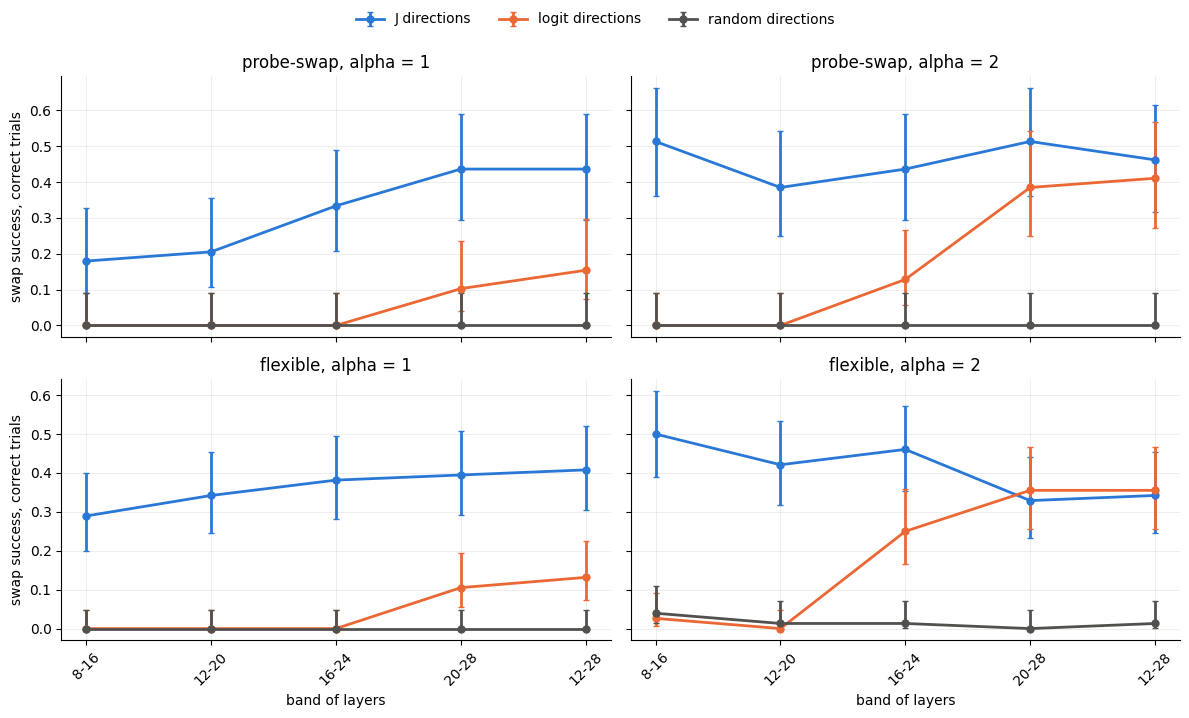

In [15]:
COLORS = {"J": "#2a78d6", "logit": "#eb6834", "random": "#52514e"}
sets = list(results.set.unique())
fig, axes = plt.subplots(len(sets), len(ALPHAS), figsize=(6 * len(ALPHAS), 3.6 * len(sets)),
                         sharex=True, sharey="row", squeeze=False)
for row, name in enumerate(sets):
    for col, alpha in enumerate(ALPHAS):
        ax = axes[row][col]
        for mode, color in COLORS.items():
            sub = grouped[grouped.set.eq(name) & grouped["mode"].eq(mode) & grouped.alpha.eq(alpha)]
            if sub.empty:
                continue
            sub = sub.set_index("band").loc[BANDS]
            rate = sub["sum"] / sub["size"]
            lo, hi = wilson(sub["sum"], sub["size"])
            ax.errorbar(range(len(BANDS)), rate, yerr=[rate - lo, hi - rate], color=color,
                        marker="o", ms=5, lw=2, capsize=2, label=f"{mode} directions")
        ax.set_title(f"{name}, alpha = {alpha:g}")
        ax.grid(alpha=0.25, lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
    axes[row][0].set_ylabel("swap success, correct trials")
for ax in axes[-1]:
    ax.set_xticks(range(len(BANDS)))
    ax.set_xticklabels(BANDS, rotation=45)
    ax.set_xlabel("band of layers")
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

### Median log10 rank gain of the swap answer

In [16]:
results["log10 rank gain"] = np.log10(results.base_rank_swap) - np.log10(results.rank_swap)
display(results.groupby(["set", "mode", "alpha", "band"])["log10 rank gain"]
        .median().unstack("band")[BANDS].round(2))

band                     8-16  12-20  16-24  20-28  12-28
set        mode   alpha                                  
flexible   J      1.0    0.53   0.90   1.07   1.29   1.43
                  2.0    1.42   1.40   1.49   1.41   1.38
           logit  1.0    0.02   0.05   0.09   0.36   0.48
                  2.0    0.11   0.13   0.31   1.23   1.34
           random 1.0    0.00   0.03   0.01   0.03   0.07
                  2.0    0.16   0.10   0.12   0.03   0.20
probe-swap J      1.0    0.70   1.06   1.22   1.46   1.46
                  2.0    1.46   1.43   1.46   1.51   1.46
           logit  1.0    0.08   0.05   0.16   0.55   0.60
                  2.0    0.18   0.30   0.41   1.43   1.43
           random 1.0    0.01   0.06   0.00   0.04   0.00
                  2.0    0.15   0.05   0.08   0.00   0.14

### Per-category breakdown of the best J setting

In [17]:
best_j = best[best["mode"].eq("J")].set_index("set")[["alpha", "band"]]
pieces = []
for name, row in best_j.iterrows():
    sub = results[results.set.eq(name) & results["mode"].eq("J")
                  & results.alpha.eq(row.alpha) & results.band.eq(row.band)]
    pieces.append(sub.groupby(["set", "group"]).success.agg(["mean", "size"]))
display(pd.concat(pieces).round(3))

mean  size
set        group                           
flexible   animals/class        0.250     4
           animals/group        0.000     1
           animals/habitat      0.500     2
           animals/legs         0.167     6
           countries/capital    1.000    12
           countries/continent  1.000    12
           countries/currency   0.667     6
           countries/language   0.667     9
           months/holiday       0.000     3
           months/next_month    0.083    12
           months/season        0.000     3
           numbers/double       0.000     3
           numbers/successor    0.000     3
probe-swap animal-nose          0.000     1
           city-capital         0.800     5
           city-continent       0.667     3
           city-currency        0.000     1
           city-language        1.000     3
           city-state           1.000     1
           element-state        0.000     2
           element-symbol       0.500     2
           food-animal          0.000     1
           fruit-grows          1.000     1
           holiday-month        1.000     1
           language-capital     0.750     4
           multihop             0.400     5
           person-country       0.000     1
           person-firstname     0.250     4
           planet-feature       0.000     1
           river-capital        1.000     1
           season-next          0.000     1
           vehicle-power        0.000     1

### Worked examples

In [18]:
shown = results[results["mode"].eq("J") & results.success]
display(shown.head(12)[["set", "name", "source", "target", "answer", "swap_answer",
                        "band", "alpha", "top1"]])

,set,name,source,target,answer,swap_answer,band,alpha,top1
3,probe-swap,amazon-language,Brazil,Mexico,Portuguese,Spanish,8-16,2.0,Spanish
18,probe-swap,amazon-language,Brazil,Mexico,Portuguese,Spanish,20-28,1.0,Spanish
21,probe-swap,amazon-language,Brazil,Mexico,Portuguese,Spanish,20-28,2.0,Spanish
24,probe-swap,amazon-language,Brazil,Mexico,Portuguese,Spanish,12-28,1.0,Spanish
27,probe-swap,amazon-language,Brazil,Mexico,Portuguese,Spanish,12-28,2.0,Spanish
63,probe-swap,city-state-Philadelphia,Philadelphia,Seattle,Pennsylvania,Washington,8-16,2.0,Washington
69,probe-swap,city-state-Philadelphia,Philadelphia,Seattle,Pennsylvania,Washington,12-20,2.0,Washington
75,probe-swap,city-state-Philadelphia,Philadelphia,Seattle,Pennsylvania,Washington,16-24,2.0,Washington
81,probe-swap,city-state-Philadelphia,Philadelphia,Seattle,Pennsylvania,Washington,20-28,2.0,Washington
87,probe-swap,city-state-Philadelphia,Philadelphia,Seattle,Pennsylvania,Washington,12-28,2.0,Washington


## 4. Conclusions

All numbers are on the 115 trials the model answers correctly without intervention, with
scorable answers (§2).

* **Swapping a J-lens coordinate changes the computed answer.** The best J setting reaches
  50% (flexible, alpha 2, band 8-16, 38 of 76) and 51% (two-hop, alpha 2, band 20-28, 20 of
  39). This is the paper's central causal claim and it reproduces.
* **The effect is specific to the lens directions.** Random directions matched to the J
  update's per-position norm succeed in at most 3.9% (flexible) and 0% (two-hop) of trials,
  with Wilson intervals that do not come close to the J arm's. Whatever the clamp is doing,
  it is not "a large enough perturbation changes the output".
* **`J_l` is what carries the concept in the first half of the network.** Logit-lens
  directions — the identical clamp with `J_l = I` — score **exactly 0.000** at bands 8-16,
  12-20 and 16-24 on both sets at alpha 1, and 0.000-0.026 in the two earliest bands at
  alpha 2, where J-lens directions reach 0.39-0.51. The median rank gain tells the same
  story: at alpha 1 in band 8-16 it is 0.53-0.70 decades for J and 0.02-0.08 for logit.
  Logit directions become competitive only from band 20-28 upward (alpha 2: 0.36-0.41 vs J
  0.33-0.51), which is where `J_l` is already close to the identity (cos(W_U, W_U J_l) >=
  0.53 by layer 24, see `lens_dataset.ipynb` §5). This is the cleanest result in this
  directory, and the one that most directly supports reading the mid-network residual
  stream through `J_l` rather than through the unembedding alone.
* **Strength and depth trade off.** Early bands need alpha = 2; the late band 20-28 is the
  only one where alpha = 1 is already strong on two-hop (0.44). This matches the GPT-2 run.
* **Where it does not work.** The per-category breakdown is bimodal: `countries/capital`
  and `countries/continent` flip 12/12, `city-language` 3/3, `language-capital` 3/4 — but
  every arithmetic or sequence category is at zero (`numbers/double`, `numbers/successor`,
  `months/next_month` 1/12). Swapping a concept vector changes a *lookup*; it does not
  reroute a computation.
* **Caveats.** 115 correctly answered trials, so per-cell counts are 39-76 and the intervals
  are wide. The correctness gate is a batched bf16 pass, and its correct set differs
  slightly from the previous unbatched run's (76 vs 79 flexible trials). Bands are fractions of depth, not a measured
  workspace. `spelling_ids` makes ranks tokenizer-dependent, so the absolute numbers are not
  comparable to the GPT-2 XL run — only the direction of each contrast is. bf16 throughout,
  matching the dtype the lens was fitted in.